In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
 transforms.ToTensor(),
  transforms.Normalize((0.5,), (0.5,))
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform,  download=True)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

100%|██████████| 170M/170M [00:37<00:00, 4.54MB/s]


In [ ]:
def train(model, optimizer, epochs=10):
    model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    losses = []
    accuracies = []
    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0
        model.train()
        for imgs, labels in trainloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        avg_loss = total_loss / len(trainloader)
        accuracy = 100.0 * correct / total
        losses.append(avg_loss)
        accuracies.append(accuracy)
        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {accuracy:.2f}%")
    return losses, accuracies

In [19]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        self.fc1 = nn.Linear(3 * 32 * 32, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10) # 10 classes for CIFAR-10

    def forward(self, x):
        x = x.view(-1, 3 * 32 * 32) # Flatten the image
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model_sgd = MLP()
sgd = optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)
losses_sgd, acc_sgd = train(model_sgd, sgd)
model_adam = MLP()
adam = optim.Adam(model_adam.parameters(), lr=0.001)
losses_adam, acc_adam = train(model_adam, adam)


Epoch 1: Loss = 1.7172, Accuracy = 39.29%
Epoch 2: Loss = 1.5079, Accuracy = 47.39%
Epoch 3: Loss = 1.4153, Accuracy = 50.37%
Epoch 4: Loss = 1.3493, Accuracy = 52.94%
Epoch 5: Loss = 1.3001, Accuracy = 54.78%
Epoch 6: Loss = 1.2533, Accuracy = 56.42%
Epoch 7: Loss = 1.2161, Accuracy = 57.84%
Epoch 8: Loss = 1.1816, Accuracy = 58.86%
Epoch 9: Loss = 1.1523, Accuracy = 60.08%
Epoch 10: Loss = 1.1224, Accuracy = 61.06%
Epoch 1: Loss = 1.6483, Accuracy = 42.01%
Epoch 2: Loss = 1.4532, Accuracy = 49.20%
Epoch 3: Loss = 1.3707, Accuracy = 52.28%
Epoch 4: Loss = 1.3067, Accuracy = 54.45%
Epoch 5: Loss = 1.2575, Accuracy = 56.13%
Epoch 6: Loss = 1.2171, Accuracy = 57.63%
Epoch 7: Loss = 1.1787, Accuracy = 59.20%
Epoch 8: Loss = 1.1386, Accuracy = 60.55%
Epoch 9: Loss = 1.1113, Accuracy = 61.36%
Epoch 10: Loss = 1.0760, Accuracy = 62.54%


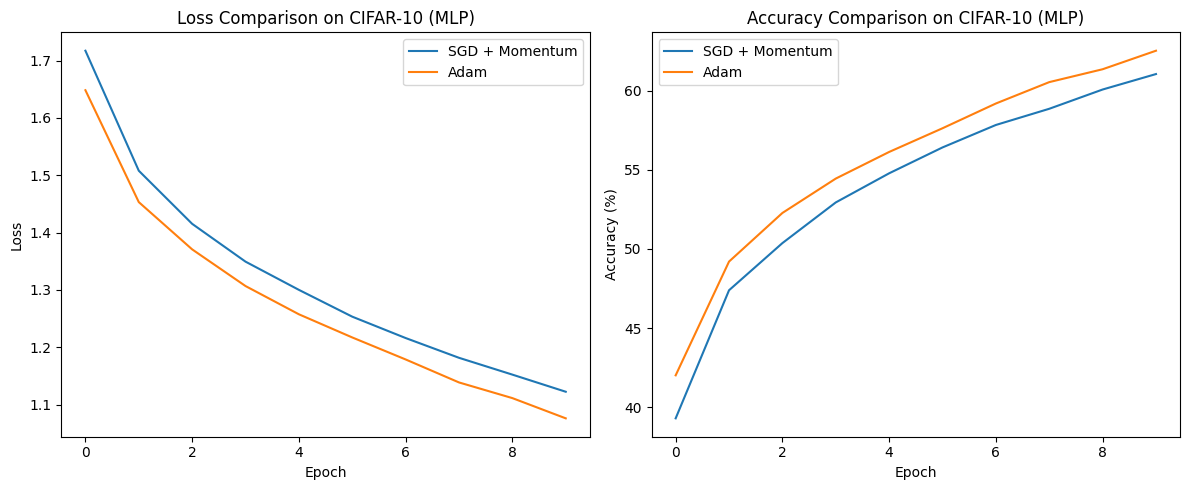

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses_sgd, label="SGD + Momentum")
plt.plot(losses_adam, label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison on CIFAR-10 (MLP)")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(acc_sgd, label="SGD + Momentum")
plt.plot(acc_adam, label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison on CIFAR-10 (MLP)")
plt.legend()
plt.tight_layout()
plt.show()